In [ ]:
#Cluster contents
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans


path = "Zepto_Reviews.csv"
df = pd.read_csv(path)


reviews = df['Review Text'].dropna().astype(str) #drop NaN values and ensure all entries are strings
#------------------------------------------------------------ Loading of data----------------------------------------------------------------------------------------#

vectorizer = TfidfVectorizer(max_df=0.9, min_df=5, stop_words='english') #if word appears in more than 90% of documents or less than 5 documents, ignore it

X = vectorizer.fit_transform(reviews) #create vocabulary and generate TF-IDF matrix

print("Shape of TF-IDF Matrix:", X.shape) # columns are unique words, rows are reviews


num_clusters = 5 #input number of clusters

kmeans = KMeans(n_clusters=num_clusters, random_state=42) #initial centroids will be chosen randomly- same random state for reproducibility
kmeans.fit(X) #seggregate reviews into clusters in X

df['Cluster'] = kmeans.labels_ #

for i in range(num_clusters): #retrieve and print first 5 reviews from each cluster
    print(f"Cluster {i}")
    temp_result = df[df['Cluster'] == i]['Review Text'].head(5)
    print(temp_result)

Shape of TF-IDF Matrix: (1000, 85)
Cluster 0
39                 reasonable price buy more n more
127                        price is little bit high
248      price should be improved compare to others
258    I got a crazy discounted price on earphones.
356           very nice recommended for goods price
Name: Review Text, dtype: object
Cluster 1
3               good
7     good enough 👍🏻
8               good
11          good app
12              good
Name: Review Text, dtype: object
Cluster 2
1                   nice
14             very nice
17         Nice discount
18    good and nice appp
19             very nice
Name: Review Text, dtype: object
Cluster 3
0     free delivery 🙌, should I can get in every order
2                                      bad app scammer
5                                pehle order toh aajay
6                                 beautiful plate from
9    Best app brooo i love it price timing in fact ...
Name: Review Text, dtype: object
Cluster 4
4                 

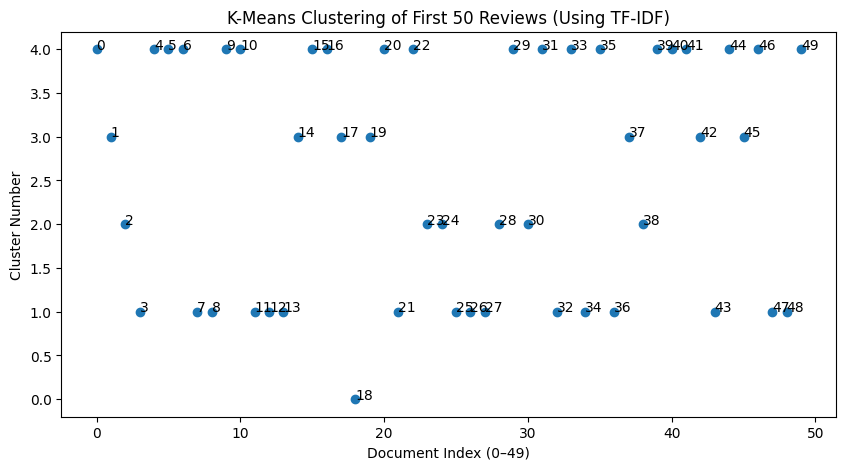

In [ ]:
#Cluster display
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

path = "Zepto_Reviews.csv"
df = pd.read_csv(path)

df = df.head(50)
reviews = df['Review Text']

vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(reviews) #vectorized form of reviews

kmeans = KMeans(n_clusters=5, random_state=42)
df['Cluster'] = kmeans.fit_predict(X)

doc_index = list(range(len(df)))     #document indices from 0 to 49- x-axis
clusters = df['Cluster']             #cluster assignments for each document- y-axis

plt.figure(figsize=(10,5))  #baground setting
plt.scatter(doc_index, clusters)    #scatter plot

for i in range(len(df)):    #annotate each point with its document index
    plt.text(doc_index[i], clusters[i], str(i)) #labels for each coordinate point

plt.xlabel("Document Index (0–49)")
plt.ylabel("Cluster Number")
plt.title("K-Means Clustering of First 50 Reviews (Using TF-IDF)")
plt.show()


Shape of TF-IDF Matrix: (1000, 333)


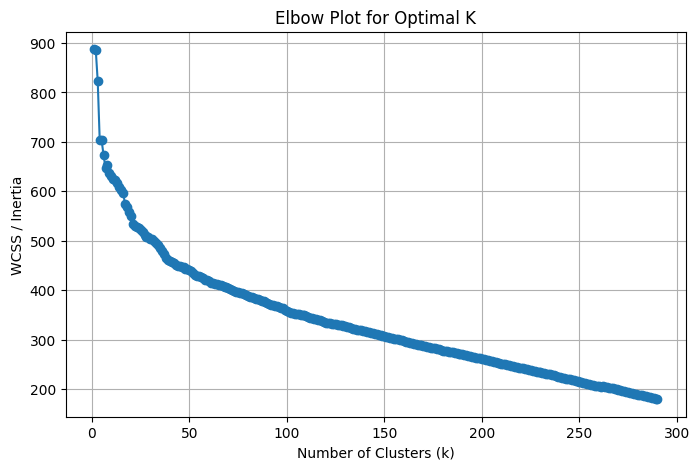

In [ ]:
#Elbow diagram
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

path = "Zepto_Reviews.csv"
df = pd.read_csv(path)

reviews = df['Review Text'].dropna().astype(str)

vectorizer = TfidfVectorizer(max_df=0.9, min_df=5, stop_words='english')
X = vectorizer.fit_transform(reviews)

print("Shape of TF-IDF Matrix:", X.shape)

wcss = []   # Within cluster sum of squares (also called inertia)- y-axis

K_range = range(1, 291) # x-axis- number of clusters

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42) #cluster object
    km.fit(X)   #cluster will be created
    wcss.append(km.inertia_)   # inertia_ = WCSS, property or attribute of KMeans object

# Plot Elbow Graph
plt.figure(figsize=(8, 5))
plt.plot(K_range, wcss, marker='o')
plt.title("Elbow Plot for Optimal K")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS / Inertia")
plt.grid(True)
plt.show()


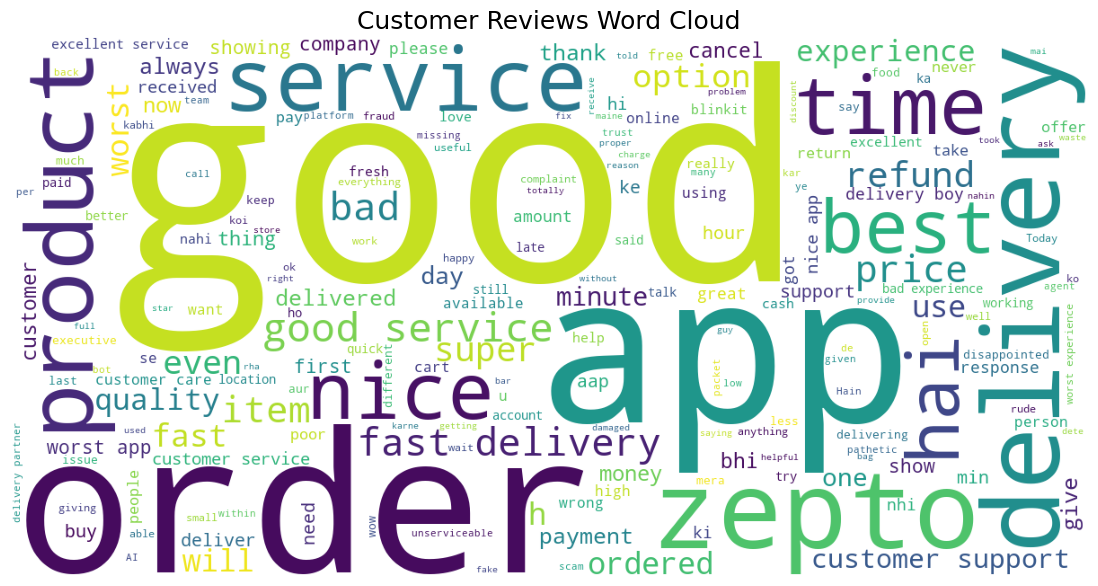

In [6]:
#Wordcloud
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

path = r"Zepto_Reviews.csv"
df = pd.read_csv(path)

reviews = df['Review Text'].dropna().astype(str)

text = " ".join(reviews) #combine all reviews into a single string for word cloud generation- joined up view

# Generate word cloud
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    max_words=200,
    colormap='viridis', #color scheme
    stopwords=None
).generate(text) 

#image rather than graph
plt.figure(figsize=(15, 7))
plt.imshow(wordcloud)
plt.axis('off') #no relation to frequency only size
plt.title("Customer Reviews Word Cloud", fontsize=18)
plt.show()

In [ ]:
# %pip install wordcloud

   ---------------------------------------- 0.0/299.9 kB ? eta -:--:--
   --- ----------------------------------- 30.7/299.9 kB 445.2 kB/s eta 0:00:01
   ------- ------------------------------- 61.4/299.9 kB 656.4 kB/s eta 0:00:01
   --------------- ---------------------- 122.9/299.9 kB 901.1 kB/s eta 0:00:01
   -------------------------------------- - 286.7/299.9 kB 1.5 MB/s eta 0:00:01
   ---------------------------------------- 299.9/299.9 kB 1.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\29pra\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
